<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Items: [0.5, 0.7, 0.3, 0.9, 0.2, 0.6, 0.8, 0.4, 0.1, 0.5]
Capacity: 1.0
Total Size: 5.0
Lower Bound: 5

First Fit: 6 bins
Bin 1: [0.5, 0.3, 0.2] | Used: 1.00 [####################]
Bin 2: [0.7, 0.1] | Used: 0.80 [###############     ]
Bin 3: [0.9] | Used: 0.90 [##################  ]
Bin 4: [0.6, 0.4] | Used: 1.00 [####################]
Bin 5: [0.8] | Used: 0.80 [################    ]
Bin 6: [0.5] | Used: 0.50 [##########          ]

FFD: 6 bins
Bin 1: [0.9] | Used: 0.90 [##################  ]
Bin 2: [0.8, 0.1] | Used: 0.90 [##################  ]
Bin 3: [0.7, 0.3] | Used: 1.00 [####################]
Bin 4: [0.6, 0.4] | Used: 1.00 [####################]
Bin 5: [0.5, 0.5] | Used: 1.00 [####################]
Bin 6: [0.2] | Used: 0.20 [####                ]

BFD: 6 bins
Bin 1: [0.9] | Used: 0.90 [##################  ]
Bin 2: [0.8, 0.1] | Used: 0.90 [##################  ]
Bin 3: [0.7, 0.3] | Used: 1.00 [####################]
Bin 4: [0.6, 0.4] | Used: 1.00 [####################]
Bin 5: [0.5, 

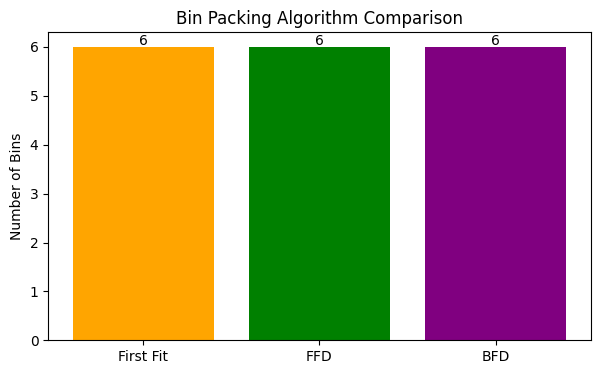

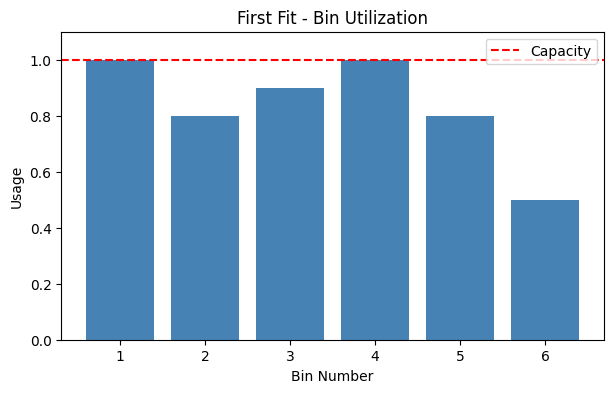

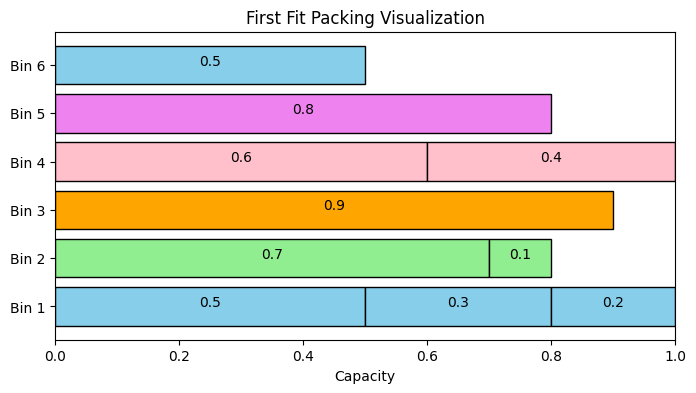

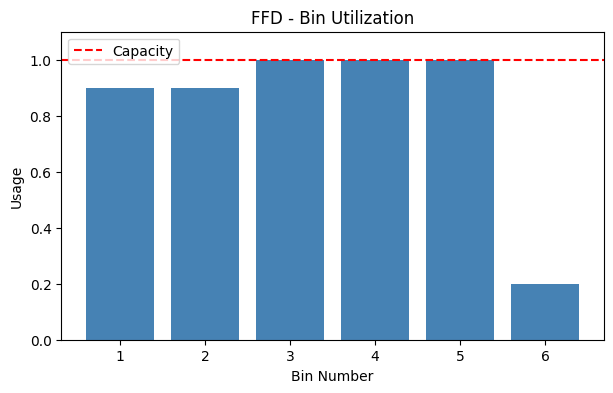

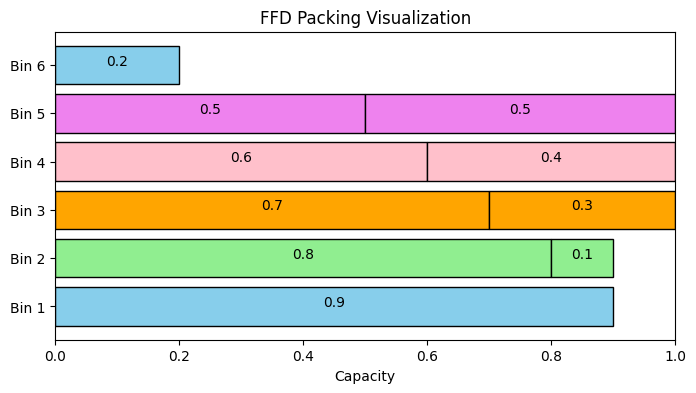

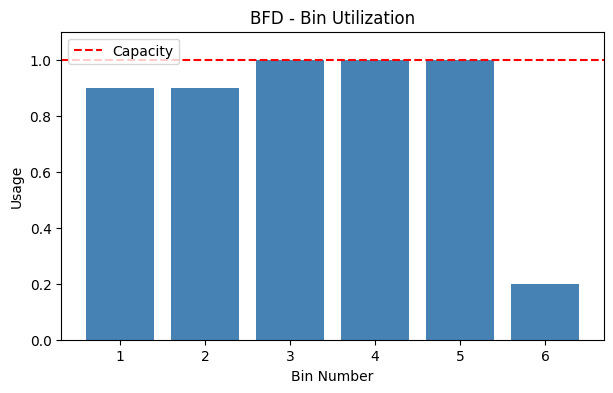

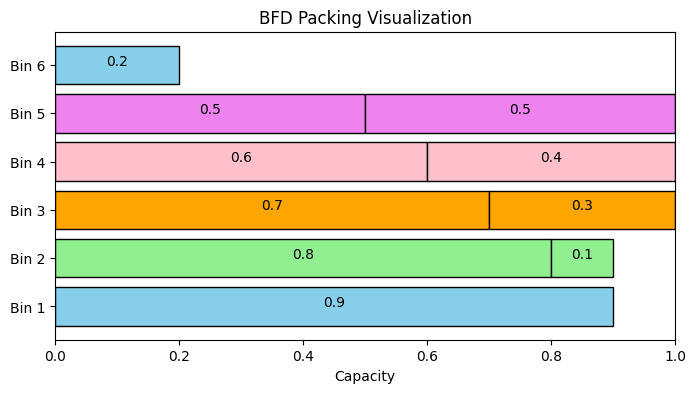

In [7]:
import matplotlib.pyplot as plt


# -------------------------------------------------
# First Fit Algorithm
# -------------------------------------------------
def first_fit(items, capacity=1.0):

    bins = []
    bin_contents = []

    for item in items:

        placed = False

        for i, space in enumerate(bins):

            if space >= item:

                bins[i] -= item
                bin_contents[i].append(item)

                placed = True
                break

        if not placed:

            bins.append(capacity - item)
            bin_contents.append([item])

    return bin_contents



# -------------------------------------------------
# First Fit Decreasing
# -------------------------------------------------
def first_fit_decreasing(items, capacity=1.0):

    return first_fit(
        sorted(items, reverse=True),
        capacity
    )



# -------------------------------------------------
# Best Fit Decreasing
# -------------------------------------------------
def best_fit_decreasing(items, capacity=1.0):

    sorted_items = sorted(items, reverse=True)

    bins = []
    bin_contents = []


    for item in sorted_items:

        best_idx = -1
        best_space = float('inf')


        for i, space in enumerate(bins):

            if space >= item and space - item < best_space:

                best_space = space - item
                best_idx = i


        if best_idx >= 0:

            bins[best_idx] -= item
            bin_contents[best_idx].append(item)


        else:

            bins.append(capacity-item)
            bin_contents.append([item])


    return bin_contents



# -------------------------------------------------
# Display Result
# -------------------------------------------------
def display_bins(label, bins):

    print(f"\n{label}: {len(bins)} bins")

    for i, b in enumerate(bins, 1):

        used = sum(b)

        bar = "#" * int(used * 20)

        print(
            f"Bin {i}: {[round(x,2) for x in b]}"
            f" | Used: {used:.2f}"
            f" [{bar:<20}]"
        )



# -------------------------------------------------
# Graph 1: Bin Utilization
# -------------------------------------------------
def plot_bin_usage(name, bins):

    usage = [
        sum(b)
        for b in bins
    ]


    plt.figure(figsize=(7,4))

    plt.bar(
        range(1,len(bins)+1),
        usage,
        color="steelblue"
    )

    plt.axhline(
        1,
        color="red",
        linestyle="--",
        label="Capacity"
    )

    plt.xlabel("Bin Number")
    plt.ylabel("Usage")

    plt.title(
        f"{name} - Bin Utilization"
    )

    plt.ylim(0,1.1)

    plt.legend()

    plt.show()



# -------------------------------------------------
# Graph 2: Method Comparison
# -------------------------------------------------
def compare_methods(results):

    names=list(results.keys())

    values=[
        len(results[x])
        for x in names
    ]


    plt.figure(figsize=(7,4))


    plt.bar(
        names,
        values,
        color=[
            "orange",
            "green",
            "purple"
        ]
    )


    for i,v in enumerate(values):

        plt.text(
            i,
            v+0.05,
            str(v),
            ha="center"
        )


    plt.ylabel("Number of Bins")

    plt.title(
        "Bin Packing Algorithm Comparison"
    )


    plt.show()



# -------------------------------------------------
# Graph 3: Visual Bin Packing
# -------------------------------------------------
def draw_packing(name, bins):

    plt.figure(figsize=(8,4))


    colors=[
        "skyblue",
        "lightgreen",
        "orange",
        "pink",
        "violet"
    ]


    for i,b in enumerate(bins):

        start=0

        for item in b:

            plt.barh(
                i,
                item,
                left=start,
                color=colors[i%len(colors)],
                edgecolor="black"
            )

            plt.text(
                start+item/2,
                i,
                str(item),
                ha="center"
            )

            start += item


    plt.yticks(
        range(len(bins)),
        [f"Bin {i+1}" for i in range(len(bins))]
    )


    plt.xlim(0,1)

    plt.xlabel("Capacity")

    plt.title(
        f"{name} Packing Visualization"
    )

    plt.show()



# =================================================
# MAIN PROGRAM
# =================================================


items = [
    0.5,0.7,0.3,0.9,
    0.2,0.6,0.8,0.4,
    0.1,0.5
]


capacity = 1.0


lower_bound = int(
    -(-sum(items)//capacity)
)


print("Items:",items)

print("Capacity:",capacity)

print("Total Size:",sum(items))

print(
    "Lower Bound:",
    lower_bound
)



ff_bins = first_fit(items)

ffd_bins = first_fit_decreasing(items)

bfd_bins = best_fit_decreasing(items)



results = {

    "First Fit":ff_bins,

    "FFD":ffd_bins,

    "BFD":bfd_bins
}



for name,b in results.items():

    display_bins(
        name,
        b
    )



print(
    "\nSummary:"
)

print(
    f"Lower Bound={lower_bound}, "
    f"FF={len(ff_bins)}, "
    f"FFD={len(ffd_bins)}, "
    f"BFD={len(bfd_bins)}"
)



# Visual Outputs

compare_methods(results)


for name,b in results.items():

    plot_bin_usage(
        name,
        b
    )

    draw_packing(
        name,
        b
    )